In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")

print("Path to dataset files:", path)

100%|██████████| 1.74G/1.74G [00:10<00:00, 187MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis/versions/1


In [4]:
print("Path:", path)
print(os.listdir(path))

Path: /root/.cache/kagglehub/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis/versions/1
['val', 'test', 'train']


In [22]:
train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'val')
test_dir = os.path.join(path, 'test')


In [8]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [23]:
print(os.listdir(test_dir))

['TURBERCULOSIS', 'PNEUMONIA', 'NORMAL', 'COVID19']


In [36]:
for cls in ["PNEUMONIA", "NORMAL"]:
  folder_path = os.path.join(train_dir, cls)
  print(cls, len(os.listdir(folder_path)))

PNEUMONIA 3875
NORMAL 1341


In [28]:
pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")
normal_dir = os.path.join(train_dir, "NORMAL")

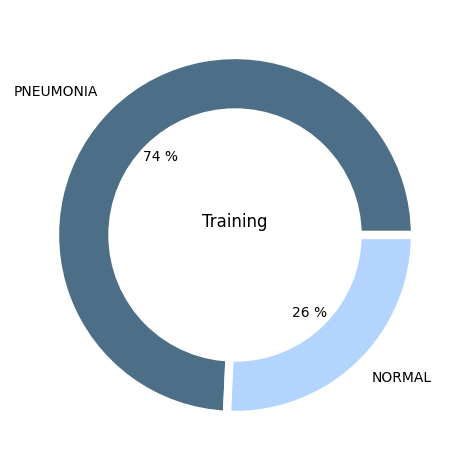

In [54]:
plt.pie([len(os.listdir(pneumonia_dir)), len(os.listdir(normal_dir))], labels=['PNEUMONIA', 'NORMAL'], colors= ['#4c6f87', '#b3d4ff','#8fb3d9', '#e1f0ff'], autopct='%.0f %%', wedgeprops={'linewidth': 6, 'edgecolor': 'white'})
my_circle = plt.Circle((0, 0), 0.70, color='white')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.axis('off')
plt.title('Training', x=0.5, y=0.5)
plt.tight_layout()

In [31]:
files = os.listdir(pneumonia_dir)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

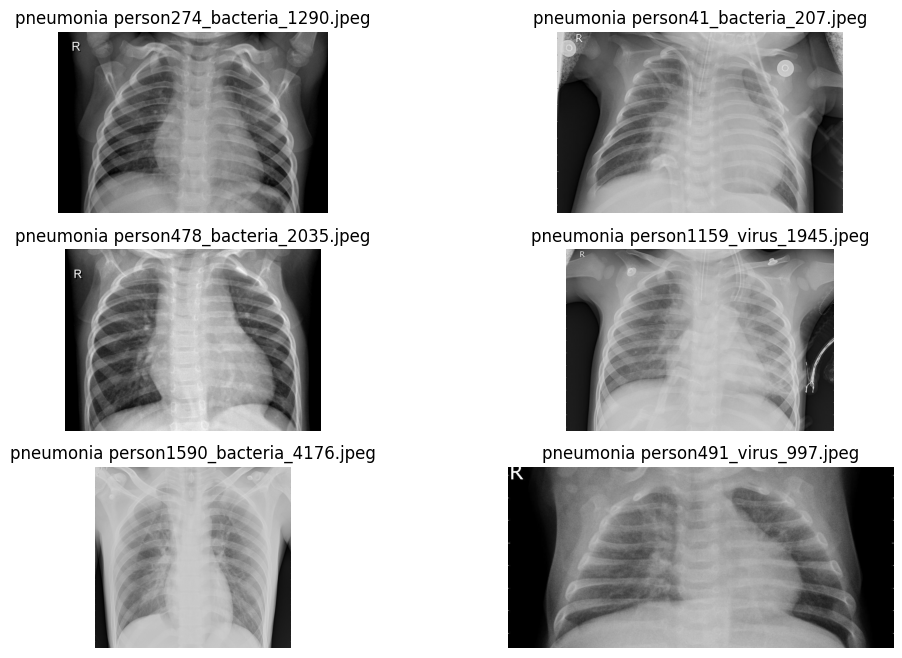

In [34]:
plt.figure(figsize=(12, 8))
for i in range(6):
  img_path = os.path.join(pneumonia_dir, files[i])
  img = Image.open(img_path)

  plt.subplot(3, 2, i + 1)
  plt.imshow(img, cmap='gray')
  plt.title(f"pneumonia {files[i]}")
  plt.axis('off')

plt